# Plan de compras 2025

Notebook para cargar las instrucciones desde `plan.md`, procesar `plan_de_compras_2025.xlsx`, aplicar las transformaciones indicadas, validar resultados y exportar la salida.

## 1. Definir rutas de archivos y dependencias

Se importan las librerías necesarias y se definen las rutas de trabajo para el plan, el archivo Excel y los archivos de salida.

In [19]:
import importlib
import subprocess
import sys
from pathlib import Path

required_packages = {
    'pandas': 'pandas',
    'openpyxl': 'openpyxl',
    'matplotlib': 'matplotlib',
}

missing_packages = []
for module_name, package_name in required_packages.items():
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        missing_packages.append(package_name)

if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

base_path = Path.cwd()
plan_path = base_path / 'plan.md'
excel_path = base_path / 'plan_de_compras_2025.xlsx'
output_excel_path = base_path / 'plan_de_compras_2025_procesado.xlsx'
summary_csv_path = base_path / 'resumen_nulos_plan_2025.csv'

for candidate in [plan_path, excel_path]:
    if not candidate.exists():
        raise FileNotFoundError(f'No se encontró el archivo requerido: {candidate}')

print('Ruta del plan:', plan_path)
print('Ruta del Excel:', excel_path)
print('Salida procesada:', output_excel_path)

Ruta del plan: /home/patricio/Documentos/github/ia-produccion/plan.md
Ruta del Excel: /home/patricio/Documentos/github/ia-produccion/plan_de_compras_2025.xlsx
Salida procesada: /home/patricio/Documentos/github/ia-produccion/plan_de_compras_2025_procesado.xlsx


## 2. Cargar el contenido de `plan.md`

Se leen las instrucciones del plan y se muestran en el notebook para mantener trazabilidad del procesamiento.

In [20]:
plan_text = plan_path.read_text(encoding='utf-8')
print(plan_text)

# Plan de trabajo
1. carga un dataframe desde la planilla excel
2. Convierte los titulos de las columnas en lowercase

## Transformaciones
Realiza las transformaciones solicitadas en el orden indicado:

1. Solicitar el ingreso de un 'codigo' de proyecto, y eliminar los registros que en el valor de la columna 'id proyecto' no terminen en el 'codigo' ingresado (evaluado en uppercase).

2. crea una nueva columna llamada 'anexo' que debe contener los 4 ultimos digitos de la columna 'teléfono responsable' extraidos a partir del segundo guión '-'.

3. elimina espacios, y todos los guiones ('-') dentro de la columna 'teléfono responsable'. 

## Analisis exploratorio

Realiza un análisis exploratorio para detectar y mostrar:

- Cantidad de valores nulos por columna, en cantidad y mostrar porcentaje de nulos.
- Propone eliminar la columna con los valores nulos mas altos. Para ello espera respuesta (SI/NO) y elimina si responde 'SI'.

## Resumenes

Crea y visualiza las siguientes tablas resumene

## 3. Inspeccionar la estructura de `plan_de_compras_2025.xlsx`

Se revisan las hojas disponibles, la forma del archivo y los nombres reales de columnas antes de aplicar cambios.

In [21]:
excel_file = pd.ExcelFile(excel_path)
print('Hojas disponibles:', excel_file.sheet_names)

raw_df = pd.read_excel(excel_path)
print('Dimensiones originales:', raw_df.shape)
print('Columnas originales:')
for column in raw_df.columns:
    print('-', repr(column))

raw_df.head()

Hojas disponibles: ['PLAN DE COMPRAS 2025']
Dimensiones originales: (831, 26)
Columnas originales:
- 'Unidad de Compra'
- 'ID Proyecto'
- 'Tipo Proyecto'
- 'Estado Proyecto'
- 'Código presupuestario'
- 'Nombre Proyecto'
- 'Descripción Proyecto'
- 'Cantidad de Ítems'
- 'Nombre ítem'
- 'Tipo compra'
- 'Cantidad Productos'
- 'Monto Unitario Ítem'
- 'Monto Total Ítem Año 2025'
- 'Cantidad OC'
- 'Meses envío OC'
- 'Nombre responsable'
- 'Cargo responsable'
- 'Teléfono responsable'
- 'Correo responsable'
- 'Fecha de Inicio Compra'
- 'Fecha Publicación PAC 2025'
- 'Cantidad OC Asociadas Ítem 2025'
- 'OC Asociada Item 2025'
- 'Item De Arraste'
- 'Monto De Arrastre'
- 'Meses envio OC de Arraste'


,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Cantidad de Ítems,Nombre ítem,Tipo compra,Cantidad Productos,Monto Unitario Ítem,Monto Total Ítem Año 2025,Cantidad OC,Meses envío OC,Nombre responsable,Cargo responsable,Teléfono responsable,Correo responsable,Fecha de Inicio Compra,Fecha Publicación PAC 2025,Cantidad OC Asociadas Ítem 2025,OC Asociada Item 2025,Item De Arraste,Monto De Arrastre,Meses envio OC de Arraste
0,Ministerio de Vivienda y Urbanismo(766),587-259-PC22,Proyecto estratégico,Publicado,33,Servicio arriendo de una plataforma de gestión...,Servicio de arriendo de una plataforma de gest...,2,Servicio arriendo de una plataforma de gestión...,1,1,125000000,20000000,3,"Abr 2023,Ene 2024,Ene 2025",María Teresa Zúñiga Silva,Coordinadora de Tecnologías Informáticas | Sis...,2 -2901 1198-,mzunigas@minvu.cl,2022-11-01,2022-11-08,0,NaN,1,20000000,2025-01-01
1,SEREMI MINVU V REGION,632-28-PC22,Proyecto operacional,Publicado,22.06.001,Servicio de Mantención y Reparaciones Menores ...,Convenio de Suministro para el Servicio de Man...,1,Mantenimiento y Reparación de Edificaciones,1,1,20000000,4500000,5,"May 2022,Nov 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-02-01,2022-11-08,1,632-7-SE22,1,4500000,2025-01-01
2,SEREMI MINVU V REGION,632-32-PC22,Proyecto operacional,Publicado,22.04.001,Servicios de Impresión-Seremi Valparaiso,Servicios de Impresión de Materiales SEREMI y ...,1,Materiales de Oficina,1,1,15300000,3825000,4,"Oct 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,0,NaN,1,3825000,2025-01-01
3,SEREMI MINVU V REGION,632-34-PC22,Proyecto operacional,Publicado,22.09.006,Servicio de Arriendo de Impresoras Multifuncio...,Servicio de Arriendo de Impresoras Multifuncio...,2,Arriendo de Equipos Informáticos,1,1,18000000,4500000,6,"Oct 2022,Nov 2022,Dic 2022,Ene 2023,Ene 2024,E...",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,1,632-13-CC23,1,4500000,2025-01-01
4,SEREMI MINVU V REGION,632-41-PC22,Proyecto operacional,Publicado,22.05.005,Servicio de Telefonía Fija-Seremi Valparaiso,Servicio de Telefonía Fija SEREMI,2,Telefonía Fija,1,1,105600000,26400000,4,"Ene 2023,Ene 2024,Ene 2025,Ene 2026",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,322186802,agardaix@minvu.cl,2022-12-01,2022-11-08,0,NaN,1,26400000,2025-01-01


## 4. Leer hojas y normalizar datos

Se cargan los datos, se normalizan los nombres de columnas y se estandarizan tipos y valores faltantes.

In [22]:
df = raw_df.copy()
df.columns = df.columns.str.strip().str.lower()
df = df.replace({'': pd.NA})

print('Columnas normalizadas:')
print(df.columns.tolist())
print('Registros cargados:', len(df))

df.head()

Columnas normalizadas:
['unidad de compra', 'id proyecto', 'tipo proyecto', 'estado proyecto', 'código presupuestario', 'nombre proyecto', 'descripción proyecto', 'cantidad de ítems', 'nombre ítem', 'tipo compra', 'cantidad productos', 'monto unitario ítem', 'monto total ítem año 2025', 'cantidad oc', 'meses envío oc', 'nombre responsable', 'cargo responsable', 'teléfono responsable', 'correo responsable', 'fecha de inicio compra', 'fecha publicación pac 2025', 'cantidad oc asociadas ítem 2025', 'oc asociada item 2025', 'item de arraste', 'monto de arrastre', 'meses envio oc de arraste']
Registros cargados: 831


,unidad de compra,id proyecto,tipo proyecto,estado proyecto,código presupuestario,nombre proyecto,descripción proyecto,cantidad de ítems,nombre ítem,tipo compra,cantidad productos,monto unitario ítem,monto total ítem año 2025,cantidad oc,meses envío oc,nombre responsable,cargo responsable,teléfono responsable,correo responsable,fecha de inicio compra,fecha publicación pac 2025,cantidad oc asociadas ítem 2025,oc asociada item 2025,item de arraste,monto de arrastre,meses envio oc de arraste
0,Ministerio de Vivienda y Urbanismo(766),587-259-PC22,Proyecto estratégico,Publicado,33,Servicio arriendo de una plataforma de gestión...,Servicio de arriendo de una plataforma de gest...,2,Servicio arriendo de una plataforma de gestión...,1,1,125000000,20000000,3,"Abr 2023,Ene 2024,Ene 2025",María Teresa Zúñiga Silva,Coordinadora de Tecnologías Informáticas | Sis...,2 -2901 1198-,mzunigas@minvu.cl,2022-11-01,2022-11-08,0,NaN,1,20000000,2025-01-01
1,SEREMI MINVU V REGION,632-28-PC22,Proyecto operacional,Publicado,22.06.001,Servicio de Mantención y Reparaciones Menores ...,Convenio de Suministro para el Servicio de Man...,1,Mantenimiento y Reparación de Edificaciones,1,1,20000000,4500000,5,"May 2022,Nov 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-02-01,2022-11-08,1,632-7-SE22,1,4500000,2025-01-01
2,SEREMI MINVU V REGION,632-32-PC22,Proyecto operacional,Publicado,22.04.001,Servicios de Impresión-Seremi Valparaiso,Servicios de Impresión de Materiales SEREMI y ...,1,Materiales de Oficina,1,1,15300000,3825000,4,"Oct 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,0,NaN,1,3825000,2025-01-01
3,SEREMI MINVU V REGION,632-34-PC22,Proyecto operacional,Publicado,22.09.006,Servicio de Arriendo de Impresoras Multifuncio...,Servicio de Arriendo de Impresoras Multifuncio...,2,Arriendo de Equipos Informáticos,1,1,18000000,4500000,6,"Oct 2022,Nov 2022,Dic 2022,Ene 2023,Ene 2024,E...",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,1,632-13-CC23,1,4500000,2025-01-01
4,SEREMI MINVU V REGION,632-41-PC22,Proyecto operacional,Publicado,22.05.005,Servicio de Telefonía Fija-Seremi Valparaiso,Servicio de Telefonía Fija SEREMI,2,Telefonía Fija,1,1,105600000,26400000,4,"Ene 2023,Ene 2024,Ene 2025,Ene 2026",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,322186802,agardaix@minvu.cl,2022-12-01,2022-11-08,0,NaN,1,26400000,2025-01-01


## 5. Interpretar instrucciones del plan

Se transforman las instrucciones del archivo Markdown en una lista de pasos ejecutables para documentar qué hará el notebook.

In [23]:
execution_steps = [
    'Convertir títulos de columnas a minúsculas',
    "Filtrar registros donde 'id proyecto' termine en 'PC25'",
    "Crear la columna 'anexo' desde 'teléfono responsable'",
    "Eliminar espacios y guiones de 'teléfono responsable'",
    'Calcular nulos y porcentajes por columna',
    'Pedir confirmación para eliminar la columna con más nulos',
    "Crear resúmenes por 'nombre responsable' y por 'nombre ítem'",
    'Generar gráficos y exportar el archivo procesado',
]

pd.DataFrame({'paso': range(1, len(execution_steps) + 1), 'descripcion': execution_steps})

,paso,descripcion
0,1,Convertir títulos de columnas a minúsculas
1,2,Filtrar registros donde 'id proyecto' termine ...
2,3,Crear la columna 'anexo' desde 'teléfono respo...
3,4,Eliminar espacios y guiones de 'teléfono respo...
4,5,Calcular nulos y porcentajes por columna
5,6,Pedir confirmación para eliminar la columna co...
6,7,Crear resúmenes por 'nombre responsable' y por...
7,8,Generar gráficos y exportar el archivo procesado


## 6. Aplicar transformaciones al archivo Excel

Se ejecutan en el orden solicitado el filtro por `PC25`, la creación de `anexo` y la limpieza del teléfono responsable.

In [24]:
rows_before = len(df)
df['id proyecto'] = df['id proyecto'].astype('string').str.strip()
df = df[df['id proyecto'].str.endswith('PC25', na=False)].copy()
rows_after = len(df)

phone_series = df['teléfono responsable'].fillna('').astype(str).str.strip()
phone_parts = phone_series.str.split('-', n=2)
df['anexo'] = phone_parts.str[2].fillna('').str.replace(r'\D', '', regex=True).str[-4:]
df['teléfono responsable'] = phone_series.str.replace(r'[\s-]+', '', regex=True)

print(f'Registros antes del filtro: {rows_before:,}')
print(f'Registros después del filtro: {rows_after:,}')
print(f'Registros eliminados: {rows_before - rows_after:,}')

df[['id proyecto', 'teléfono responsable', 'anexo']].head(10)

Registros antes del filtro: 831
Registros después del filtro: 648
Registros eliminados: 183


,id proyecto,teléfono responsable,anexo
183,1583-4-PC25,0229011170,
184,1583-4-PC25,0229011170,
185,1583-4-PC25,0229011170,
186,1583-5-PC25,29011170,
187,1583-5-PC25,29011170,
188,1583-5-PC25,29011170,
189,1583-5-PC25,29011170,
190,1583-6-PC25,29011170,
191,1583-8-PC25,29011170,
192,1583-8-PC25,29011170,


### limpiar codigo eliminando puntos (.)

In [25]:
## eliminar los puntos '.' dentro de la columna 'código presupuestario' y convertirla a tipo string
df['código presupuestario'] = df['código presupuestario'].astype('string').str.replace('.', '', regex=False)

Los codigos presupuestarios estan ahora en el mismo formato de los codigos en planilla 'codigos_unicos.xlsx'.

crear un dataframe con los codigos unicos y reemplazar en el plan de compras el 'nombre de proyecto' con el nombre respectivo de los codigos basados en el campo 'codigo presupuestario'

In [26]:
# dataframe con los codigos unicos. leer la planilla codigos_unicos.xlsx y crear un dataframe con los codigos unicos
codigos = pd.read_excel('codigos_unicos.xlsx')
codigos.shape

(62, 2)

In [27]:
codigos[['Codigo', 'Nombre']].head(10)

,Codigo,Nombre
0,33,Servicio arriendo de una plataforma de gestión...
1,2204,Servicio de impresión_SEREMI
2,2205,Servicio de Telefonia Satelital- Sección Contr...
3,2206,Mantención preventiva de Relojes antiguos (36 ...
4,2207,SERVICIO DE EMPASTES Y ENCUADERNACION
5,2208,Servicio del limpieza interna y externa y exte...
6,2209,Arriendo de impresoras multifuncionales- Secci...
7,2211,Mantencion Control de Acceso MINVU (36 meses)
8,2903,COMPRA VEHICULOS - SECCION CONTROL BIENES
9,2904,ADQUISICIÓN DE SILLAS ERGONÓMICAS


In [28]:
df[['código presupuestario', 'nombre proyecto']].head(10)

,código presupuestario,nombre proyecto
183,2204007,INSUMOS PARA DISPENSADORES - ADMINISTRACIÓN DE...
184,2204007,INSUMOS PARA DISPENSADORES - ADMINISTRACIÓN DE...
185,2204007,INSUMOS PARA DISPENSADORES - ADMINISTRACIÓN DE...
186,2204010,MATERIAL DE ASEO-1-ADMINISTRACIÓN DE INSUMOS
187,2204010,MATERIAL DE ASEO-1-ADMINISTRACIÓN DE INSUMOS
188,2204010,MATERIAL DE ASEO-1-ADMINISTRACIÓN DE INSUMOS
189,2204010,MATERIAL DE ASEO-1-ADMINISTRACIÓN DE INSUMOS
190,2204007,MATERIAL DE ASEO-2 - ADMINISTRACIÓN DE INSUMOS
191,2204007,MATERIAL DE ESCRITORIO-1 - ADMINISTRACIÓN DE I...
192,2204007,MATERIAL DE ESCRITORIO-1 - ADMINISTRACIÓN DE I...


In [29]:
codigos.columns
codigos.head(2)

,Codigo,Nombre
0,33,Servicio arriendo de una plataforma de gestión...
1,2204,Servicio de impresión_SEREMI


In [30]:
# reemplazar los valores de la columna 'nombre proyecto' en el dataframe df con los valores correspondientes en el dataframe codigos basados en el valor de la columna 'código presupuestario' y 'codigo' del dataframe codigos.
""" df = df.merge(codigos[['Codigo', 'Nombre']], how='left', left_on='código presupuestario', right_on='Codigo')
df['nombre proyecto'] = df['Nombre']
df = df.drop(columns=['Nombre', 'Codigo'])
df[['código presupuestario', 'nombre proyecto']].sample(10) """

" df = df.merge(codigos[['Codigo', 'Nombre']], how='left', left_on='código presupuestario', right_on='Codigo')\ndf['nombre proyecto'] = df['Nombre']\ndf = df.drop(columns=['Nombre', 'Codigo'])\ndf[['código presupuestario', 'nombre proyecto']].sample(10) "

realizar un join entre el dataframe df y el dataframe codigos basado en la columna 'Código Presupuestario' de df y la columna 'Codigo' de codigos, para obtener los nombres de los proyectos correspondientes a cada código presupuestario. Reemplazar los valores de la columna 'nombre proyecto' en el dataframe df con los valores correspondientes de 'Nombre' en el dataframe codigos basados en el valor de la columna 'código presupuestario' y 'Codigo' del dataframe codigos.


In [37]:
# verificar cuántos registros tienen nombre proyecto nulo antes del join
print('Nulos en nombre proyecto antes:', df['nombre proyecto'].isna().sum())

df = df.merge(codigos[['Codigo', 'Nombre']], how='left', left_on='código presupuestario', right_on='Codigo')
df['nombre proyecto'] = df['Nombre'].combine_first(df['nombre proyecto'])
df = df.drop(columns=['Nombre', 'Codigo'])

print('Nulos en nombre proyecto después:', df['nombre proyecto'].isna().sum())
df[['código presupuestario', 'nombre proyecto']].head(10)

Nulos en nombre proyecto antes: 0
Nulos en nombre proyecto después: 0


,código presupuestario,nombre proyecto
0,2204007,INSUMOS PARA DISPENSADORES - ADMINISTRACIÓN DE...
1,2204007,INSUMOS PARA DISPENSADORES - ADMINISTRACIÓN DE...
2,2204007,INSUMOS PARA DISPENSADORES - ADMINISTRACIÓN DE...
3,2204010,MATERIAL DE ASEO-1-ADMINISTRACIÓN DE INSUMOS
4,2204010,MATERIAL DE ASEO-1-ADMINISTRACIÓN DE INSUMOS
5,2204010,MATERIAL DE ASEO-1-ADMINISTRACIÓN DE INSUMOS
6,2204010,MATERIAL DE ASEO-1-ADMINISTRACIÓN DE INSUMOS
7,2204007,MATERIAL DE ASEO-2 - ADMINISTRACIÓN DE INSUMOS
8,2204007,MATERIAL DE ESCRITORIO-1 - ADMINISTRACIÓN DE I...
9,2204007,MATERIAL DE ESCRITORIO-1 - ADMINISTRACIÓN DE I...


## 7. Validar resultados y detectar inconsistencias

Se revisan nulos, porcentajes, tipos numéricos y se propone eliminar la columna con más nulos previa confirmación.

In [32]:
null_summary = pd.DataFrame({
    'nulos': df.isna().sum(),
    'porcentaje_nulos': (df.isna().mean() * 100).round(2),
}).sort_values(by=['nulos', 'porcentaje_nulos'], ascending=False)

null_summary.to_csv(summary_csv_path)
null_summary

,nulos,porcentaje_nulos
meses envio oc de arraste,648,100.00
oc asociada item 2025,54,8.33
código presupuestario,1,0.15
unidad de compra,0,0.00
id proyecto,0,0.00
tipo proyecto,0,0.00
estado proyecto,0,0.00
nombre proyecto,0,0.00
descripción proyecto,0,0.00
cantidad de ítems,0,0.00


In [33]:
column_to_drop = null_summary.index[0]
null_count = int(null_summary.iloc[0]['nulos'])
null_percentage = float(null_summary.iloc[0]['porcentaje_nulos'])

print(
    f"Se propone eliminar la columna '{column_to_drop}' porque tiene {null_count} nulos ({null_percentage:.2f}%)."
)

try:
    user_choice = input('¿Deseas eliminarla? Responde SI o NO: ').strip().upper()
except EOFError:
    user_choice = 'NO'

if user_choice == 'SI':
    df = df.drop(columns=[column_to_drop])
    print(f"Columna eliminada: {column_to_drop}")
else:
    print('No se eliminó ninguna columna.')

numeric_columns = ['monto total ítem año 2025', 'monto unitario ítem']
for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

df[numeric_columns].describe()

Se propone eliminar la columna 'meses envio oc de arraste' porque tiene 648 nulos (100.00%).
No se eliminó ninguna columna.


,monto total ítem año 2025,monto unitario ítem
count,648.00,648.00
mean,"122,271,822.79","125,289,938.52"
std,"221,926,792.62","223,104,764.70"
min,0.00,"90,000.00"
25%,"3,500,000.00","3,800,000.00"
50%,"202,000,000.00","202,000,000.00"
75%,"202,000,000.00","202,000,000.00"
max,"4,839,000,000.00","4,839,000,000.00"


## 8. Guardar archivo procesado y evidencias

Se crean los resúmenes solicitados, se generan gráficos y se exportan tanto el Excel procesado como evidencias auxiliares.

In [34]:
totales_por_responsable = (
    df.groupby('nombre responsable', dropna=False)['monto total ítem año 2025']
    .sum(min_count=1)
    .sort_values(ascending=False)
    .reset_index()
)

top_10_items_caros = (
    df[['nombre ítem', 'nombre responsable', 'monto unitario ítem']]
    .sort_values(by='monto unitario ítem', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

items_mas_comprados = (
    df.groupby('nombre ítem', dropna=False)
    .agg(
        cantidad_compras=('nombre ítem', 'size'),
        monto_unitario_promedio=('monto unitario ítem', 'mean'),
        monto_unitario_maximo=('monto unitario ítem', 'max'),
    )
    .sort_values(by=['cantidad_compras', 'monto_unitario_maximo'], ascending=False)
    .reset_index()
)

print('Totales por responsable')
display(totales_por_responsable.head(10))
print('Top 10 ítems más caros')
display(top_10_items_caros)
print('Ítems más comprados')
display(items_mas_comprados.head(10))

Totales por responsable


,nombre responsable,monto total ítem año 2025
0,"MALHUE GUIÑEZ, MARIA ANGELICA",64851217000
1,CAVIERES CORDOBA LEONARDO RODRIGO,6612952000
2,"LABBE SALDIAS, CRISTIAN ALFONSO",1800000000
3,"SILVA AGUILAR, VICTOR MANUEL",1653517298
4,"Gascon Huerta, Luis Humberto",972894147
5,"Rudloff Kuttner, Cristian Heriberto",800000000
6,"MORENO GONZALEZ, PAOLA MARISOL",383000000
7,CARCENAC MARIANGEL PAULINA,326624590
8,"IBAEZ TAPIA, ELPIDA",230450000
9,Claudio Paredes Pizarro,200000000


Top 10 ítems más caros


,nombre ítem,nombre responsable,monto unitario ítem
0,CONTRATO LICENCIAMIENTO MICROSOFT (2025-2027) ...,CAVIERES CORDOBA LEONARDO RODRIGO,4839000000
1,LICENCIAMIENTO SOFTWARE GEORREFERENCIACIÓN (AR...,"LABBE SALDIAS, CRISTIAN ALFONSO",1800000000
2,CAMPAÑA PUBLICITARIA POSTULACIONES A SUBSIDIOS...,"Rudloff Kuttner, Cristian Heriberto",800000000
3,Renovación contrato servicios de datacenter co...,Leonardo Cavieres Córdoba,760400000
4,COMPRA VEHICULOS - SECCION CONTROL BIENES,"SILVA AGUILAR, VICTOR MANUEL",406548702
5,COMPRA VEHICULOS - SECCION CONTROL BIENES,"SILVA AGUILAR, VICTOR MANUEL",406548702
6,COMPRA VEHICULOS - SECCION CONTROL BIENES,"SILVA AGUILAR, VICTOR MANUEL",406548702
7,COMPRA VEHICULOS - SECCION CONTROL BIENES,"SILVA AGUILAR, VICTOR MANUEL",406548702
8,Art. Aseo e higiene,Augusto Bratz Riquelme,400000000
9,ADQUISICIÓN DE WORKTATION - DINFO,CAVIERES CORDOBA LEONARDO RODRIGO,390000000


Ítems más comprados


,nombre ítem,cantidad_compras,monto_unitario_promedio,monto_unitario_maximo
0,ADQUISICIÓN PASAJES - SECCION GESTION DE COMPRAS,321,"202,000,000.00",202000000
1,MANTENCION DE VEHICULOS - SECCION MOVILIZACION,23,"40,000,000.00",40000000
2,COMPRA DE ALIMENTOS PERECIBLES SEPTIEMBRE - JA...,8,"3,800,000.00",3800000
3,TARJETAS VESTUARIO,7,"6,370,428.57",19740000
4,COMPRA DE ALIMENTOS PERECIBLES MARZO - JARDÍN ...,5,"3,500,000.00",3500000
5,COMPRA VEHICULOS - SECCION CONTROL BIENES,4,"406,548,702.00",406548702
6,MATERIAL DE ESCRITORIO-1 - ADMINISTRACIÓN DE I...,4,"15,000,000.00",15000000
7,COMPRA DE ALIMENTOS PERECIBLES JUNIO - JARDÍN ...,4,"3,500,000.00",3500000
8,MATERIAL DE ASEO-1 - ADMINISTRACIÓN DE INSUMOS,4,"2,300,000.00",2300000
9,INSUMOS PARA DISPENSADORES-3 - ADMINISTRACIÓN ...,3,"47,941,530.00",47941530


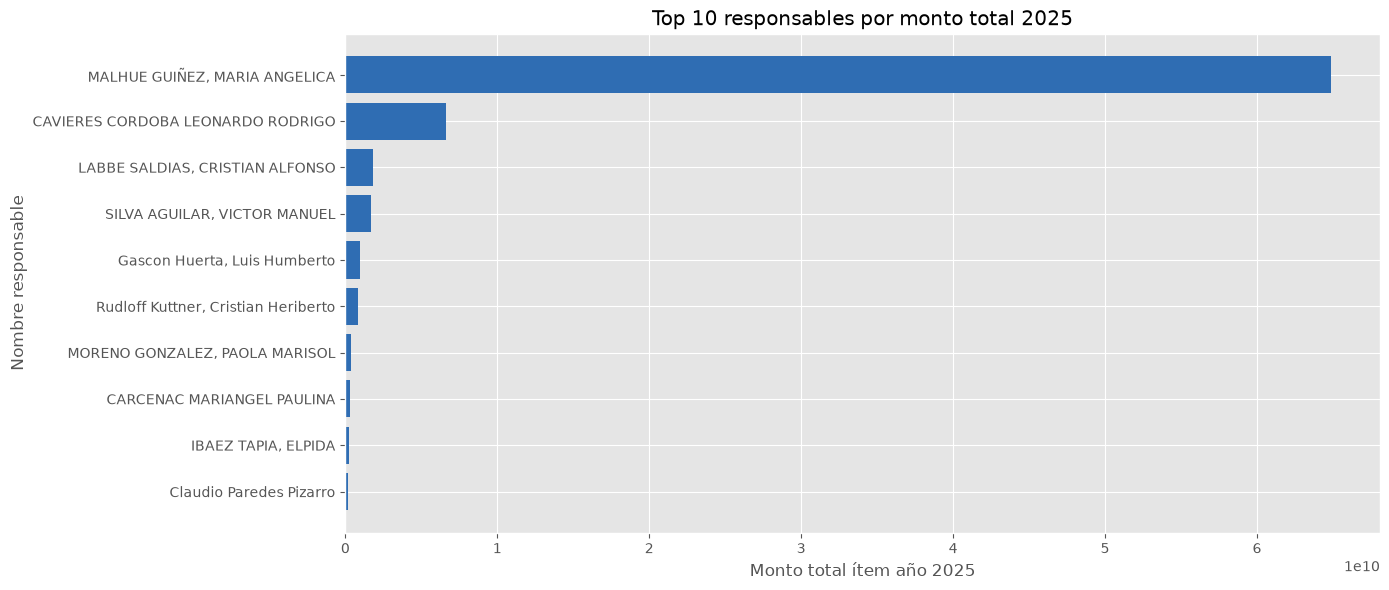

/tmp/ipykernel_93982/3331316452.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


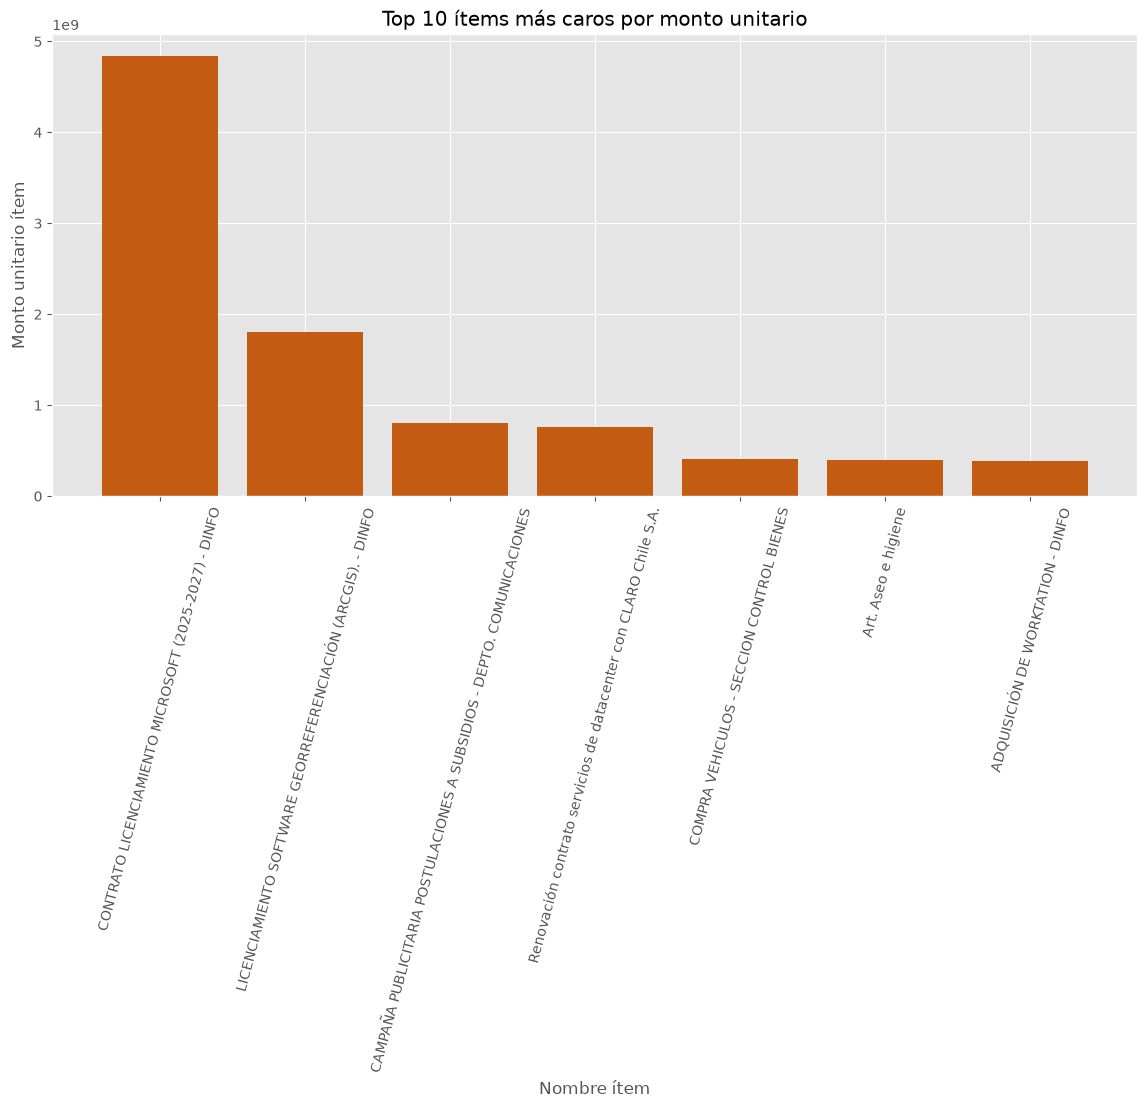

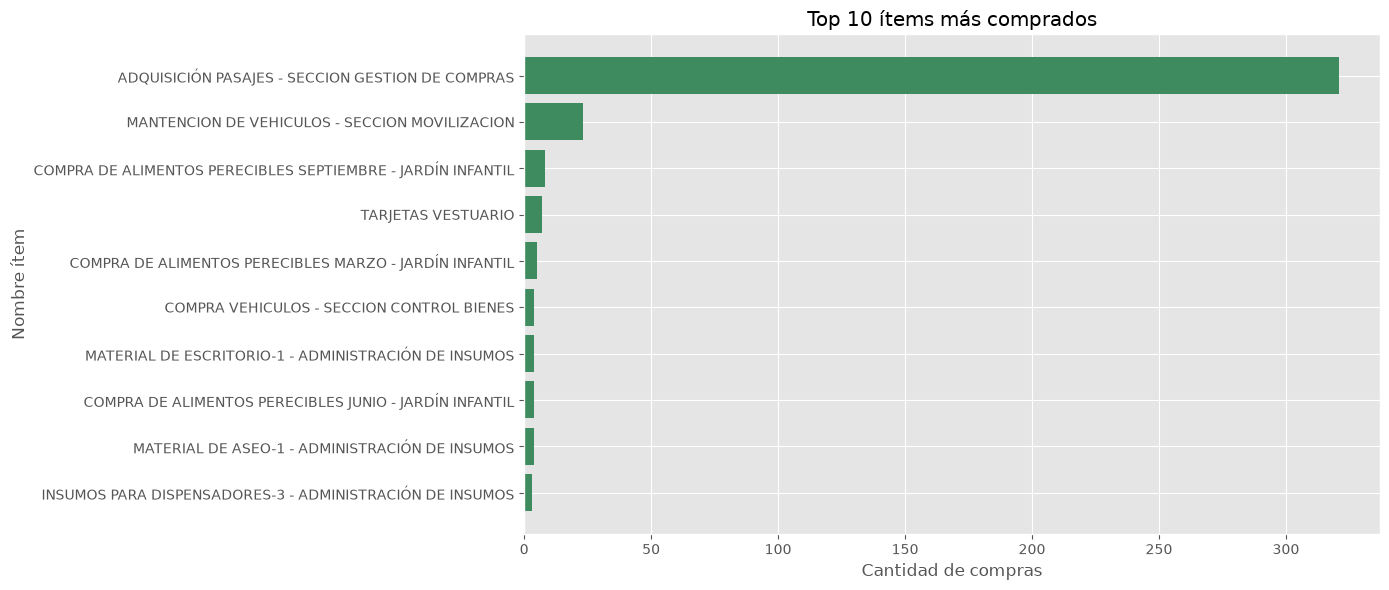

Archivo procesado generado en: /home/patricio/Documentos/github/ia-produccion/plan_de_compras_2025_procesado.xlsx
Resumen de nulos exportado en: /home/patricio/Documentos/github/ia-produccion/resumen_nulos_plan_2025.csv


In [35]:
fig1, ax1 = plt.subplots(figsize=(14, 6))
plot_responsables = totales_por_responsable.head(10).sort_values('monto total ítem año 2025')
ax1.barh(
    plot_responsables['nombre responsable'].fillna('Sin responsable'),
    plot_responsables['monto total ítem año 2025'],
    color='#2f6db3'
)
ax1.set_title('Top 10 responsables por monto total 2025')
ax1.set_xlabel('Monto total ítem año 2025')
ax1.set_ylabel('Nombre responsable')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 6))
ax2.bar(
    top_10_items_caros['nombre ítem'].fillna('Sin nombre'),
    top_10_items_caros['monto unitario ítem'],
    color='#c45b12'
)
ax2.set_title('Top 10 ítems más caros por monto unitario')
ax2.set_xlabel('Nombre ítem')
ax2.set_ylabel('Monto unitario ítem')
ax2.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

fig3, ax3 = plt.subplots(figsize=(14, 6))
plot_items = items_mas_comprados.head(10).iloc[::-1]
ax3.barh(
    plot_items['nombre ítem'].fillna('Sin nombre'),
    plot_items['cantidad_compras'],
    color='#3d8b5f'
)
ax3.set_title('Top 10 ítems más comprados')
ax3.set_xlabel('Cantidad de compras')
ax3.set_ylabel('Nombre ítem')
plt.tight_layout()
plt.show()

df.to_excel(output_excel_path, index=False)
print(f'Archivo procesado generado en: {output_excel_path.resolve()}')
print(f'Resumen de nulos exportado en: {summary_csv_path.resolve()}')

## 9. Generar resumen ejecutable del proceso

Se consolidan métricas de la ejecución para facilitar una revisión rápida del resultado.

In [36]:
execution_summary = pd.DataFrame([
    {'metrica': 'registros_originales', 'valor': rows_before},
    {'metrica': 'registros_filtrados_pc25', 'valor': rows_after},
    {'metrica': 'registros_eliminados', 'valor': rows_before - rows_after},
    {'metrica': 'columnas_finales', 'valor': len(df.columns)},
    {'metrica': 'hojas_detectadas', 'valor': len(excel_file.sheet_names)},
    {'metrica': 'archivo_salida', 'valor': str(output_excel_path.name)},
])

execution_summary

,metrica,valor
0,registros_originales,831
1,registros_filtrados_pc25,648
2,registros_eliminados,183
3,columnas_finales,27
4,hojas_detectadas,1
5,archivo_salida,plan_de_compras_2025_procesado.xlsx
